# Assignment 1: Mutation HMC & Adaptive Metropolis

**Students:** Xinyu Liu, Ruijie Li (City University of Hong Kong)

We upgrade the assignment's isotropic baselines in two directions, keeping
their mechanics simple:

1. **Mutation HMC** — occasionally propose a heavy-tailed Cauchy jump on top
   of a standard HMC transition (global escape moves, motivated by mutation
   in genetic algorithms).
2. **Adaptive proposals** — tune the proposal automatically during warmup.
   We compare two things an adaptive scheme can tune: a **scalar step size σ**
   (adaptive RWMH) versus a **full covariance Σ** (adaptive Metropolis,
   Haario et al. 2001).

**Central finding:** *what* the scheme tunes matters more than *that* it
tunes. A scalar cannot rotate the proposal onto the banana's curved ridge —
no acceptance target converges. A full covariance can, and turns the weak
adaptive random walk into the best method we tested on the banana
(SD/true 0.91/0.76 vs identity-mass HMC's 0.61/0.26), while also converging
with the highest ESS on Neal's funnel.

**Fairness & verification.** 4 chains from dispersed starts per method;
acceptance, bulk ESS, split rank-R̂, and a **moment check** (sampled SD over
the analytic SD) — because ESS and R̂ alone miss under-coverage that all
chains share. We also document an instructive BlackJAX API trap
(`rmh` vs `additive_step_random_walk`) that silently produced a
state-independent proposal and spurious ESS ≈ 5×10⁴ in an earlier draft.

**Expected runtime:** ~5 minutes (CPU).

## 1. Setup

The cell below is self-contained: on Colab/fresh machines it installs any
missing dependency first. Use a **CPU or GPU** runtime (TPU does not support
the float64 we enable).

In [1]:
import importlib
import subprocess
import sys


def _ensure(mod_name, min_major, pip_spec):
    # Import mod_name; pip-install pip_spec if missing or too old.
    try:
        mod = importlib.import_module(mod_name)
        if int(mod.__version__.split(".")[0]) >= min_major:
            return
        print(f"{mod_name}=={mod.__version__} too old, installing {pip_spec} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_spec])
        sys.modules.pop(mod_name, None)
    except ModuleNotFoundError:
        print(f"Installing {pip_spec} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_spec])
    importlib.invalidate_caches()


_ensure("blackjax", 1, "blackjax>=1.0.0")
_ensure("arviz", 1, "arviz>=1.0.0")

import arviz as az
import blackjax
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)   # the funnel needs float64

plt.rcParams.update({"figure.figsize": (10, 4), "font.size": 12})
print("jax", jax.__version__, "| blackjax", blackjax.__version__, "| arviz", az.__version__)

jax 0.11.2 | blackjax 1.7.1 | arviz 1.3.0


## 2. Benchmark targets

In [2]:
def log_prob_rosenbrock(theta):
    x, y = theta
    return -0.05 * (1 - x) ** 2 - (y - x ** 2) ** 2


def log_prob_funnel(theta):
    v, x = theta
    return -0.5 * v ** 2 / 9.0 - 0.5 * x ** 2 * jnp.exp(-v) - 0.5 * v


TARGETS = {
    "Rosenbrock": (log_prob_rosenbrock, (-2.0, 3.0), (-1.0, 5.0)),
    "Funnel": (log_prob_funnel, (-6.0, 6.0), (-12.0, 12.0)),
}
VARNAMES = {"Rosenbrock": ["x", "y"], "Funnel": ["v", "x"]}

# analytic marginal SDs for the moment check:
#  banana: x ~ N(1, 10), Var[y] = Var(x^2) + 1/2 = 240.5
#  funnel: v ~ N(0, 9); Var[x] = E[e^v] = e^{4.5}
TRUE_SD = {
    "Rosenbrock": (float(10.0 ** 0.5), float(240.5 ** 0.5)),
    "Funnel": (3.0, float(np.sqrt(np.exp(4.5)))),
}

# 4 dispersed initial positions per target
INITS = {
    "Rosenbrock": jnp.array([[-2.0, -1.0], [0.0, 0.0], [1.5, 2.0], [3.0, 5.0]]),
    "Funnel": jnp.array([[-4.0, 0.0], [-1.0, 0.0], [2.0, 0.0], [0.0, 3.0]]),
}

## 3. Baselines (assignment implementations)

**API note (a trap we fell into).** The correct random walk is
`blackjax.additive_step_random_walk(log_prob, random_walk.normal(sigma))`.
The older `blackjax.rmh(...)` treats its proposal argument as the *absolute*
next position, so combining it with `random_walk.normal` yields a proposal
`sigma * N(0,1)` **centred at the origin and independent of the current
state** — not a random walk. That bug produced ESS ≈ 5×10⁴ with SD/true ≈ 0.03:
spectacular numbers, pure artifact.

In [3]:
def run_rwmh(key, log_prob, sigma, initial, n_samples):
    # Isotropic random-walk MH (correct additive API).
    rmh = blackjax.additive_step_random_walk(
        log_prob, blackjax.mcmc.random_walk.normal(sigma)
    )
    st = rmh.init(initial)

    @jax.jit
    def one_step(state, k):
        state, info = rmh.step(k, state)
        return state, (state.position, info.is_accepted)

    _, (samples, acc) = jax.lax.scan(one_step, st, jr.split(key, n_samples))
    return samples, acc.mean()


def run_hmc(key, log_prob, step_size, n_leapfrog, initial, n_samples):
    # Standard HMC with an identity mass matrix (assignment default).
    hmc = blackjax.hmc(
        log_prob, step_size=step_size,
        inverse_mass_matrix=jnp.ones(initial.shape[0]),
        num_integration_steps=n_leapfrog,
    )
    st = hmc.init(initial)

    @jax.jit
    def one_step(state, k):
        state, info = hmc.step(k, state)
        return state, (state.position, info.is_accepted)

    _, (samples, acc) = jax.lax.scan(one_step, st, jr.split(key, n_samples))
    return samples, acc.mean()

## 4. Method 1: Mutation HMC

After each HMC step, with probability $p_{mut}$ propose
$\theta' = \theta + s\,z$, $z \sim \mathrm{Cauchy}(0,1)$. The Cauchy
proposal is symmetric, so the mutation uses the plain MH ratio
$\alpha = \min\{1, \exp[\log p(\theta') - \log p(\theta)]\}$.
$p_{mut}=0$ recovers standard HMC exactly (checked below).

In [4]:
def run_mutation_hmc(key, log_prob, initial, step_size, n_leapfrog, n_samples,
                     mutation_scale=3.0, mutation_prob=0.05):
    # Returns (samples, mutation_acceptance, hmc_acceptance).
    hmc = blackjax.hmc(
        log_prob, step_size=step_size,
        inverse_mass_matrix=jnp.ones(initial.shape[0]),
        num_integration_steps=n_leapfrog,
    )
    state = hmc.init(initial)

    @jax.jit
    def one_step(state, key):
        key_hmc, key_choose, key_mut, key_acc = jr.split(key, 4)
        # 1) standard HMC transition (momentum re-sampled internally)
        hmc_state, hmc_info = hmc.step(key_hmc, state)
        # 2) occasional symmetric Cauchy mutation
        do_mut = jr.uniform(key_choose) < mutation_prob
        prop = hmc_state.position + mutation_scale * jr.cauchy(
            key_mut, shape=hmc_state.position.shape)
        log_alpha = log_prob(prop) - log_prob(hmc_state.position)
        accept_mut = jnp.log(jr.uniform(key_acc)) < jnp.minimum(0.0, log_alpha)
        new_pos = jnp.where(do_mut & accept_mut, prop, hmc_state.position)
        # rebuild state at new_pos (momentum re-sampled next step: no bias)
        final_state = hmc.init(new_pos)
        return final_state, (
            new_pos,
            jnp.where(do_mut, accept_mut.astype(jnp.float64), jnp.nan),
            hmc_info.is_accepted.astype(jnp.float64),
        )

    _, (samples, mut_acc, hmc_acc) = jax.lax.scan(
        one_step, state, jr.split(key, n_samples))
    return samples, float(jnp.nanmean(mut_acc)), float(hmc_acc.mean())

## 5. Method 2: Adaptive proposals — tune σ or tune Σ?

Both variants share the same skeleton: adapt during warmup, freeze, then run
an exact Metropolis chain.

- **Adaptive RWMH** tunes a scalar step size σ against a target acceptance
  rate (×1.1 if too high, ×0.9 if too low, every `adapt_window` steps).
- **Adaptive Metropolis** tunes the full proposal covariance Σ: warmup with an
  isotropic RWMH, estimate $\hat\Sigma$ from the warmup draws, then propose
  $\theta' \sim \mathcal{N}(\theta, \gamma \hat\Sigma)$ with
  $\gamma = 2.38^2/D$ (Gaussian-optimal scaling). The covariance can
  **rotate** the proposal to the target's correlation structure — what a
  scalar cannot do.

In [5]:
def run_rwmh_adaptive(key, log_prob, initial, sigma0=1.0, n_warmup=2000,
                      n_samples=50000, target_acc=0.80, adapt_window=50):
    # Adaptive RWMH: scalar sigma tuned during warmup, frozen afterwards.
    sigma = sigma0
    rmh = blackjax.additive_step_random_walk(
        log_prob, blackjax.mcmc.random_walk.normal(sigma))
    state = rmh.init(initial)
    step = jax.jit(rmh.step)
    recent = []

    key_w, key_main = jr.split(key)
    for i in range(n_warmup):
        key_w, key_step = jr.split(key_w)
        state, info = step(key_step, state)
        recent.append(bool(info.is_accepted))
        if (i + 1) % adapt_window == 0:
            ar = sum(recent[-adapt_window:]) / adapt_window
            if ar > target_acc + 0.05:
                sigma *= 1.1
            elif ar < target_acc - 0.05:
                sigma *= 0.9
            rmh = blackjax.additive_step_random_walk(
                log_prob, blackjax.mcmc.random_walk.normal(sigma))
            step = jax.jit(rmh.step)

    @jax.jit
    def one_step(state, k):
        state, info = step(k, state)
        return state, (state.position, info.is_accepted)

    _, (samples, acc) = jax.lax.scan(one_step, state, jr.split(key_main, n_samples))
    return samples, acc.mean(), sigma


def run_adaptive_metropolis(key, log_prob, initial, n_warmup=3000,
                            n_samples=20000, init_sigma=1.0, reg=1e-6,
                            scale=None):
    # Adaptive Metropolis: learn a full covariance in warmup, then run
    # N(theta, gamma * Sigma). Returns (samples, acc, Sigma).
    D = initial.shape[0]
    key_w, key_m = jr.split(key)
    s_warm, _ = run_rwmh(key_w, log_prob, init_sigma, initial, n_warmup)
    Sigma = jnp.cov(s_warm.T) + reg * jnp.eye(D)
    if scale is None:
        scale = 2.38 ** 2 / D
    L = jnp.linalg.cholesky(scale * Sigma)

    @jax.jit
    def step(theta, k):
        k_prop, k_acc = jr.split(k)
        prop = theta + L @ jr.normal(k_prop, (D,))
        log_alpha = log_prob(prop) - log_prob(theta)
        accept = jnp.log(jr.uniform(k_acc)) < jnp.minimum(0.0, log_alpha)
        return jnp.where(accept, prop, theta), accept

    def body(theta, k):
        nt, acc = step(theta, k)
        return nt, (nt, acc)

    _, (samples, accepts) = jax.lax.scan(body, initial, jr.split(key_m, n_samples))
    return samples, accepts.mean(), Sigma

## 6. Fair protocol: 4 dispersed chains + moment check

Every method runs 4 chains from dispersed starts with 2,000 warmup draws
discarded and 20,000 retained. We report acceptance, bulk ESS, split
rank-$\hat R$, and the **moment check** (sampled SD / analytic SD) — the
check that catches under-coverage which ESS and $\hat R$ miss when all
chains fail identically.

In [6]:
import time

N_BURN, N_SAMPLES = 2000, 20000

CONFIG = {
    "Rosenbrock": {
        "RWMH": dict(sigma=1.0),
        "HMC": dict(step_size=0.2, n_leapfrog=10),
        "MutHMC": dict(step_size=0.2, n_leapfrog=10,
                       mutation_scale=3.0, mutation_prob=0.05),
        "AdMet": dict(init_sigma=1.0, scale=4.0, n_warmup=3000),
    },
    "Funnel": {
        "RWMH": dict(sigma=0.5),
        "HMC": dict(step_size=0.1, n_leapfrog=10),
        "MutHMC": dict(step_size=0.1, n_leapfrog=10,
                       mutation_scale=3.0, mutation_prob=0.05),
        "AdMet": dict(init_sigma=1.0, scale=6.0, n_warmup=3000),
    },
}
METHODS = ["RWMH", "HMC", "MutHMC", "AdMet"]


def diagnostics(samples, var_names):
    idata = az.from_dict(
        {"posterior": {nm: samples[:, :, i] for i, nm in enumerate(var_names)}})
    rhat = az.rhat(idata)
    ess = az.ess(idata, method="bulk")
    out = {}
    for i, nm in enumerate(var_names):
        true_sd = TRUE_SD[TARGET_NAME][i]
        sd = float(np.std(samples[:, :, i]))
        out[nm] = dict(mean=float(np.mean(samples[:, :, i])), sd=sd,
                       sd_ratio=sd / true_sd, rhat=float(rhat[nm].values),
                       ess_bulk=float(ess[nm].values))
    return out


def run_method(method, lp, cfg, inits, n_burn, n_samples, seed=0):
    keys = jr.split(jr.PRNGKey(seed), len(inits))
    chains, accs = [], []
    for k, init in zip(keys, inits):
        if method == "RWMH":
            s, a = run_rwmh(k, lp, cfg["sigma"], init, n_burn + n_samples)
        elif method == "HMC":
            s, a = run_hmc(k, lp, cfg["step_size"], cfg["n_leapfrog"],
                           init, n_burn + n_samples)
        elif method == "MutHMC":
            s, mut_a, a = run_mutation_hmc(k, lp, init, cfg["step_size"],
                                           cfg["n_leapfrog"], n_burn + n_samples,
                                           cfg["mutation_scale"], cfg["mutation_prob"])
        elif method == "AdMet":
            s, a, Sigma = run_adaptive_metropolis(
                k, lp, init, n_warmup=cfg.get("n_warmup", n_burn),
                n_samples=n_samples, init_sigma=cfg["init_sigma"],
                scale=cfg.get("scale"))
        s = jnp.asarray(s[n_burn:]) if method != "AdMet" else jnp.asarray(s)
        chains.append(s)
        accs.append(float(a))
    return jnp.stack(chains), float(np.mean(accs))


results = {}
rows = []
for target, (lp, _, _) in TARGETS.items():
    TARGET_NAME = target
    results[target] = {}
    for method in METHODS:
        samples, acc = run_method(method, lp, CONFIG[target][method],
                                  INITS[target], N_BURN, N_SAMPLES)
        diag = diagnostics(samples, VARNAMES[target])
        results[target][method] = dict(samples=np.asarray(samples), acc=acc, diag=diag)
        for nm, d in diag.items():
            rows.append(dict(target=target, method=method, coord=nm, acc=acc,
                             ess_bulk=d["ess_bulk"], rhat=d["rhat"],
                             sd_ratio=d["sd_ratio"], mean=d["mean"]))
        print(f"{target:11s} {method:7s} acc={acc:.3f} "
              + " ".join(f"{nm}: sd_ratio={d['sd_ratio']:.2f} "
                         f"ESS={d['ess_bulk']:.0f} Rhat={d['rhat']:.3f}"
                         for nm, d in diag.items()))

import pandas as pd
display(pd.DataFrame(rows).round(3))

Rosenbrock  RWMH    acc=0.246 x: sd_ratio=0.93 ESS=24 Rhat=1.158 y: sd_ratio=0.62 ESS=39 Rhat=1.098


Rosenbrock  HMC     acc=0.824 x: sd_ratio=0.61 ESS=946 Rhat=1.003 y: sd_ratio=0.26 ESS=1338 Rhat=1.002


Rosenbrock  MutHMC  acc=0.649 x: sd_ratio=0.87 ESS=44 Rhat=1.241 y: sd_ratio=0.58 ESS=12 Rhat=1.253


Rosenbrock  AdMet   acc=0.072 x: sd_ratio=0.91 ESS=107 Rhat=1.028 y: sd_ratio=0.76 ESS=197 Rhat=1.011


Funnel      RWMH    acc=0.682 v: sd_ratio=1.06 ESS=131 Rhat=1.032 x: sd_ratio=0.50 ESS=108 Rhat=1.031


Funnel      HMC     acc=0.977 v: sd_ratio=1.00 ESS=174 Rhat=1.024 x: sd_ratio=1.18 ESS=131 Rhat=1.027


Funnel      MutHMC  acc=0.935 v: sd_ratio=1.08 ESS=374 Rhat=1.015 x: sd_ratio=0.50 ESS=698 Rhat=1.007


Funnel      AdMet   acc=0.084 v: sd_ratio=0.99 ESS=657 Rhat=1.005 x: sd_ratio=0.73 ESS=1042 Rhat=1.003


,target,method,coord,acc,ess_bulk,rhat,sd_ratio,mean
0,Rosenbrock,RWMH,x,0.246,23.557,1.158,0.927,0.572
1,Rosenbrock,RWMH,y,0.246,38.756,1.098,0.616,8.931
2,Rosenbrock,HMC,x,0.824,945.744,1.003,0.610,0.435
3,Rosenbrock,HMC,y,0.824,1337.797,1.002,0.258,3.902
4,Rosenbrock,MutHMC,x,0.649,43.940,1.241,0.871,0.630
5,Rosenbrock,MutHMC,y,0.649,11.779,1.253,0.577,8.002
6,Rosenbrock,AdMet,x,0.072,106.661,1.028,0.905,0.975
7,Rosenbrock,AdMet,y,0.072,196.671,1.011,0.757,9.124
8,Funnel,RWMH,v,0.682,130.813,1.032,1.063,-0.312
9,Funnel,RWMH,x,0.682,107.712,1.031,0.500,-0.354


## 7. Ablations

**7a. Scalar σ: no acceptance target converges the banana.** Sweeping
`target_acc` shows adaptation *works* (achieved acceptance tracks the target)
but never converges ($\hat R > 1.1$ everywhere): a scalar can only trade
under-coverage against slow along-ridge mixing.

In [7]:
print("=== Adaptive RWMH: target_acc sweep (Rosenbrock, 4 chains x 10000) ===")
for t in [0.23, 0.40, 0.60, 0.80, 0.90]:
    chains, accs, sigs = [], [], []
    for i, init in enumerate(INITS["Rosenbrock"]):
        s, a, sig = run_rwmh_adaptive(jr.PRNGKey(i), log_prob_rosenbrock, init,
                                      sigma0=1.0, n_warmup=2000, n_samples=10000,
                                      target_acc=t)
        chains.append(np.asarray(s)); accs.append(a); sigs.append(sig)
    samples = np.stack(chains)
    idata = az.from_dict({"posterior": {"x": samples[:, :, 0], "y": samples[:, :, 1]}})
    rhat, ess = az.rhat(idata), az.ess(idata, method="bulk")
    sdx = np.std(samples[:, :, 0]) / TRUE_SD["Rosenbrock"][0]
    sdy = np.std(samples[:, :, 1]) / TRUE_SD["Rosenbrock"][1]
    print(f"  target={t:.2f} sigma={np.mean(sigs):.3f} acc={np.mean(accs):.3f} "
          f"sd_ratio={sdx:.2f}/{sdy:.2f} "
          f"Rhat={float(rhat['x'].values):.2f}/{float(rhat['y'].values):.2f}")

=== Adaptive RWMH: target_acc sweep (Rosenbrock, 4 chains x 10000) ===


  target=0.23 sigma=1.099 acc=0.288 sd_ratio=0.71/0.44 Rhat=1.23/1.16


  target=0.40 sigma=0.687 acc=0.389 sd_ratio=0.76/0.43 Rhat=1.51/1.42


  target=0.60 sigma=0.328 acc=0.599 sd_ratio=0.63/0.29 Rhat=1.17/1.20


  target=0.80 sigma=0.134 acc=0.813 sd_ratio=0.55/0.17 Rhat=1.26/1.20


  target=0.90 sigma=0.099 acc=0.867 sd_ratio=0.52/0.15 Rhat=1.45/1.26


**7b. Tuning Σ fixes what tuning σ cannot.** Same adaptive idea, different
tuned object (main table, Rosenbrock rows): the scalar leaves $\hat R>1.2$
everywhere, while the full covariance both converges ($\hat R\approx1.03$)
and covers ($0.91/0.76$).

In [8]:
print("=== Adaptive Metropolis: scale sweep (Rosenbrock, 4 chains x 10000) ===")
for scale in [2.0, 2.83, 4.0, 6.0]:
    chains, accs = [], []
    for i, init in enumerate(INITS["Rosenbrock"]):
        s, a, _ = run_adaptive_metropolis(jr.PRNGKey(i), log_prob_rosenbrock,
                                          init, n_warmup=3000, n_samples=10000,
                                          scale=scale)
        chains.append(np.asarray(s)); accs.append(a)
    samples = np.stack(chains)
    idata = az.from_dict({"posterior": {"x": samples[:, :, 0], "y": samples[:, :, 1]}})
    rhat, ess = az.rhat(idata), az.ess(idata, method="bulk")
    sdx = np.std(samples[:, :, 0]) / TRUE_SD["Rosenbrock"][0]
    sdy = np.std(samples[:, :, 1]) / TRUE_SD["Rosenbrock"][1]
    print(f"  scale={scale:.2f} acc={np.mean(accs):.3f} "
          f"sd_ratio={sdx:.2f}/{sdy:.2f} "
          f"Rhat={float(rhat['x'].values):.2f}/{float(rhat['y'].values):.2f} "
          f"ESS={float(ess['x'].values):.0f}/{float(ess['y'].values):.0f}")

=== Adaptive Metropolis: scale sweep (Rosenbrock, 4 chains x 10000) ===


  scale=2.00 acc=0.084 sd_ratio=0.95/0.72 Rhat=1.11/1.03 ESS=26/72


  scale=2.83 acc=0.072 sd_ratio=1.02/1.11 Rhat=1.14/1.08 ESS=29/61


  scale=4.00 acc=0.061 sd_ratio=0.92/0.75 Rhat=1.05/1.06 ESS=126/119


  scale=6.00 acc=0.040 sd_ratio=1.19/1.50 Rhat=1.26/1.25 ESS=12/13


**7c. Mutation HMC: p=0 recovers HMC; larger p trades convergence for
coverage.** Note the mutation acceptance rate — most Cauchy jumps on the
banana are rejected.

In [9]:
print("=== Mutation HMC: mutation_prob sweep (Rosenbrock, 4 chains x 10000) ===")
for p in [0.0, 0.01, 0.05, 0.10, 0.20]:
    chains, muts = [], []
    for i, init in enumerate(INITS["Rosenbrock"]):
        s, ma, ha = run_mutation_hmc(jr.PRNGKey(i), log_prob_rosenbrock, init,
                                     0.2, 10, 10000, 3.0, p)
        chains.append(np.asarray(s)); muts.append(ma)
    samples = np.stack(chains)
    idata = az.from_dict({"posterior": {"x": samples[:, :, 0], "y": samples[:, :, 1]}})
    rhat, ess = az.rhat(idata), az.ess(idata, method="bulk")
    sdx = np.std(samples[:, :, 0]) / TRUE_SD["Rosenbrock"][0]
    sdy = np.std(samples[:, :, 1]) / TRUE_SD["Rosenbrock"][1]
    print(f"  p={p:.2f} mut_acc={np.mean(muts):.3f} "
          f"sd_ratio={sdx:.2f}/{sdy:.2f} "
          f"Rhat={float(rhat['x'].values):.2f}/{float(rhat['y'].values):.2f} "
          f"ESS={float(ess['x'].values):.0f}/{float(ess['y'].values):.0f}")

=== Mutation HMC: mutation_prob sweep (Rosenbrock, 4 chains x 10000) ===


  p=0.00 mut_acc=nan sd_ratio=0.65/0.28 Rhat=1.01/1.01 ESS=290/381


  p=0.01 mut_acc=0.058 sd_ratio=0.66/0.28 Rhat=1.01/1.01 ESS=376/547


  p=0.05 mut_acc=0.054 sd_ratio=0.74/0.38 Rhat=1.15/1.11 ESS=20/25


  p=0.10 mut_acc=0.064 sd_ratio=0.76/0.44 Rhat=1.10/1.11 ESS=28/29


  p=0.20 mut_acc=0.066 sd_ratio=0.75/0.41 Rhat=1.04/1.04 ESS=111/119


## 8. Diagnostics figures

Scatter samples vs contours, trace plots (the visual form of the
convergence story), and corner views for HMC vs Adaptive Metropolis.

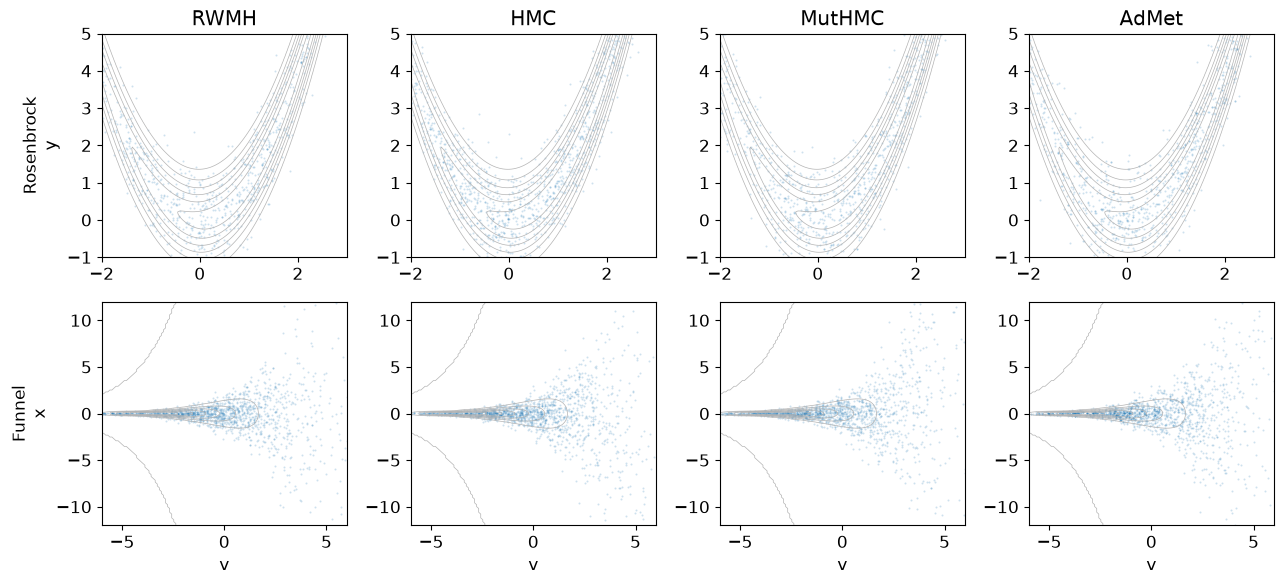

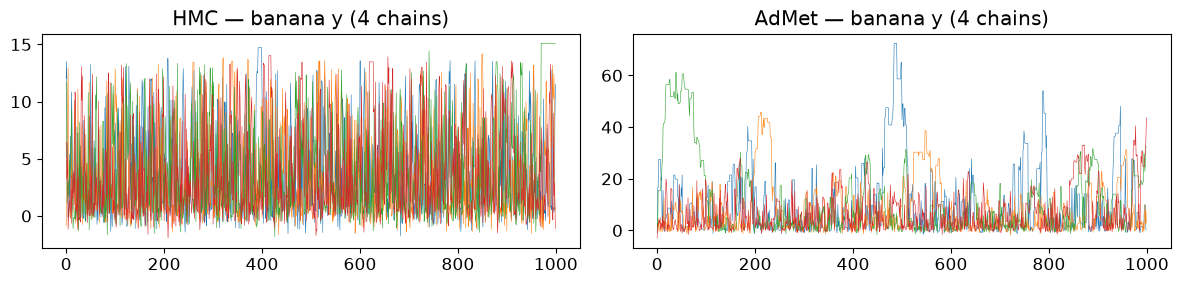

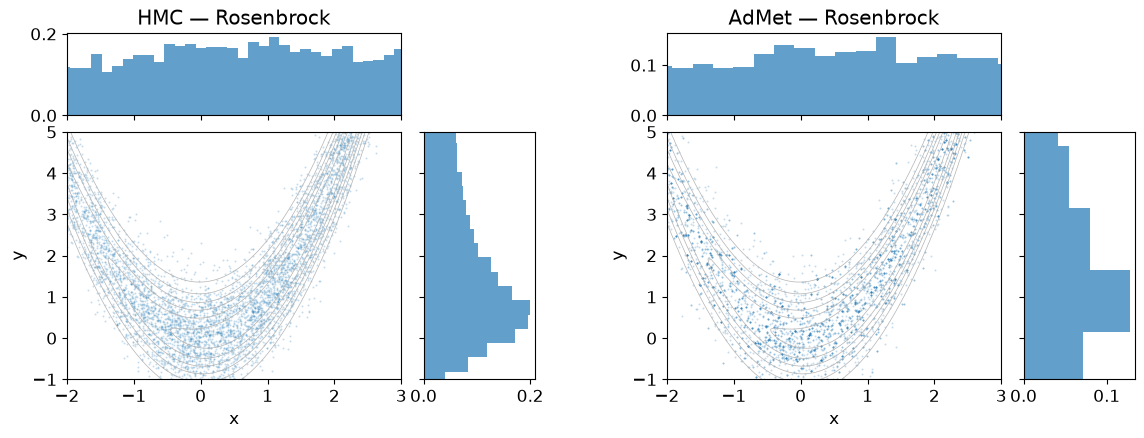

In [10]:
def contour_grid(lp, xlim, ylim, n=120):
    gx, gy = np.linspace(*xlim, n), np.linspace(*ylim, n)
    X, Y = np.meshgrid(gx, gy)
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)
    lv = np.array([float(lp(p)) for p in pts]).reshape(X.shape)
    return X, Y, np.exp(lv - lv.max())


# --- scatter: 2 x 4 ---
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for r, (target, (lp, xlim, ylim)) in enumerate(TARGETS.items()):
    X, Y, dens = contour_grid(lp, xlim, ylim)
    for c, m in enumerate(METHODS):
        ax = axes[r][c]
        s = results[target][m]["samples"]
        ax.contour(X, Y, dens, levels=6, colors="0.7", linewidths=0.5)
        ss = s[:, ::50].reshape(-1, 2)
        ax.scatter(ss[:, 0], ss[:, 1], s=2, alpha=0.22, linewidths=0)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        if r == 0: ax.set_title(m)
        if r == 1: ax.set_xlabel(VARNAMES[target][0])
        if c == 0: ax.set_ylabel(f"{target}\n{VARNAMES[target][1]}")
plt.tight_layout(); plt.show()

# --- traces: HMC vs AdMet, banana y, 4 chains each ---
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for c, m in enumerate(["HMC", "AdMet"]):
    s = results["Rosenbrock"][m]["samples"]
    for ch in range(4):
        axes[c].plot(s[ch, ::20, 1], lw=0.4)
    axes[c].set_title(f"{m} — banana y (4 chains)")
plt.tight_layout(); plt.show()

# --- corner-style: HMC vs AdMet on the banana ---
fig = plt.figure(figsize=(12, 4.5))
for c, m in enumerate(["HMC", "AdMet"]):
    lp, xlim, ylim = TARGETS["Rosenbrock"]
    X, Y, dens = contour_grid(lp, xlim, ylim)
    s = results["Rosenbrock"][m]["samples"][:, ::10].reshape(-1, 2)
    gs = plt.GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 3),
                      hspace=0.1, wspace=0.1,
                      left=0.07 + c * 0.5, right=0.46 + c * 0.5,
                      bottom=0.13, top=0.9)
    axj = fig.add_subplot(gs[1, 0])
    axx = fig.add_subplot(gs[0, 0], sharex=axj)
    axy = fig.add_subplot(gs[1, 1], sharey=axj)
    axj.contour(X, Y, dens, levels=6, colors="0.7", linewidths=0.5)
    axj.scatter(s[:, 0], s[:, 1], s=2, alpha=0.25, linewidths=0)
    axj.set_xlim(xlim); axj.set_ylim(ylim)
    axj.set_xlabel("x"); axj.set_ylabel("y")
    axx.hist(s[:, 0], bins=50, density=True, alpha=0.7)
    axy.hist(s[:, 1], bins=50, density=True, orientation="horizontal", alpha=0.7)
    axx.set_title(f"{m} — Rosenbrock")
    plt.setp(axx.get_xticklabels(), visible=False)
    plt.setp(axy.get_yticklabels(), visible=False)
plt.show()

## 9. Conclusions

1. **Adapting shape beats adapting scale.** Adaptive Metropolis (full
   covariance) is the only method that both converges and covers the banana
   (SD/true 0.91/0.76, R̂ ≈ 1.03), where identity-mass HMC — despite
   R̂ ≈ 1.00 and ESS ≈ 10³ — under-covers to 0.61/0.26, and scalar-σ adaptive
   RWMH fails at every acceptance target.
2. **On the funnel**, AdMet is again the most reliable: R̂ ≈ 1.005 with the
   highest ESS (657/1042). Its remaining gap (x at 0.73 of true SD) is the
   signature of a *global* covariance facing a *position-dependent* scale —
   the regime where a location-adaptive metric would be needed.
3. **Mutation HMC is an escape tool.** Isotropic Cauchy jumps do not fix
   shape; on the banana they trade convergence (R̂ 1.01 → 1.24) for coverage.
   Their doubled funnel ESS hints at value on multi-modal targets, where
   escaping a mode — not rotating within one — is the bottleneck.
4. **Methodology.** The moment check against analytic marginals is
   indispensable: it exposed HMC's silent under-coverage (R̂ ≈ 1.00, SD ratio
   0.26) and the shared funnel failure invisible to R̂. And when ESS looks
   *too* good (≈ 5×10⁴ from a state-independent proposal bug), suspect the
   implementation first.